In [50]:
import dgl
import torch
import pickle
import numpy as np
from pathlib import Path

def load_saved_graphs(input_path):
    """Load graphs that were saved with save_graphs()."""
    input_path = Path(input_path)

    if not input_path.exists():
        raise FileNotFoundError(f"Graph file not found: {input_path}")

    print(f"Loading graphs from {input_path}")

    # Load graphs
    graph_list, _ = dgl.load_graphs(str(input_path))

    # Load metadata
    metadata_path = input_path.with_suffix('.pkl')
    if not metadata_path.exists():
        raise FileNotFoundError(f"Metadata file not found: {metadata_path}")

    with open(metadata_path, 'rb') as f:
        metadata = pickle.load(f)

    graph_ids = metadata['graph_ids']
    graphs = {graph_id: graph for graph_id, graph in zip(graph_ids, graph_list)}

    print(f"✓ Loaded {len(graphs)} graphs")

    return graphs, metadata  # Return metadata as well

# Load the graphs
graphs, metadata = load_saved_graphs('my_graphs.bin')

Loading graphs from my_graphs.bin
✓ Loaded 500 graphs


In [51]:
# Filter graphs: keep only those where ALL edges have non-NaN patristic_distance_count
valid_graphs = {}
filtered_count = 0

for graph_id, graph in graphs.items():
    # Check if patristic_distance_count exists in edge data
    if 'patristic_distance_count' in graph.edata:
        patristic_count = graph.edata['patristic_distance_count']
        
        # Keep only graphs where ALL edges have non-NaN patristic_distance_count
        if not torch.isnan(patristic_count).any():
            valid_graphs[graph_id] = graph
        else:
            filtered_count += 1
    else:
        # If feature doesn't exist, filter out this graph
        filtered_count += 1

print(f"Original graphs: {len(graphs)}")
print(f"Filtered out (with NaN patristic_distance_count): {filtered_count}")
print(f"Valid graphs remaining: {len(valid_graphs)}")

# Replace graphs with valid_graphs
graphs = valid_graphs

Original graphs: 500
Filtered out (with NaN patristic_distance_count): 73
Valid graphs remaining: 427


In [52]:
import torch.nn as nn

class SimpleLinkPredictor(nn.Module):
    def __init__(self, node_feat_dim):
        """
        Simple link prediction model: src | dst -> MLP -> prediction
        No edge features, only node features.
        Architecture: 8 -> 32 -> 8 -> 1
        
        Args:
            node_feat_dim: Number of node features (4)
        """
        super(SimpleLinkPredictor, self).__init__()
        
        # Input: [src_features | dst_features]
        input_dim = node_feat_dim + node_feat_dim  # 4 + 4 = 8
        
        self.predictor = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    
    def forward(self, src_features, dst_features):
        """
        Forward pass.
        
        Args:
            src_features: Source node features [num_edges, node_feat_dim]
            dst_features: Destination node features [num_edges, node_feat_dim]
        
        Returns:
            predictions: Predicted migration rates [num_edges, 1]
        """
        # Concatenate: [src | dst]
        x = torch.cat([src_features, dst_features], dim=1)
        
        # Predict
        predictions = self.predictor(x)
        
        return predictions

print("✓ Simple model defined (no edge features): 8 -> 32 -> 8 -> 1")

✓ Simple model defined (no edge features): 8 -> 32 -> 8 -> 1


In [53]:
# Initialize model (no edge features)
node_feat_dim = 4  

model = SimpleLinkPredictor(node_feat_dim=node_feat_dim)

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(f"✓ Model initialized:")
print(f"  Input: {node_feat_dim} (src) + {node_feat_dim} (dst) = {node_feat_dim * 2} features")
print(f"  Architecture: 8 -> 32 -> 8 -> 1")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Loss function: MSE")
print("\n✓ Using ONLY node features (no edge features)")

✓ Model initialized:
  Input: 4 (src) + 4 (dst) = 8 features
  Architecture: 8 -> 32 -> 8 -> 1
  Total parameters: 561
  Optimizer: Adam (lr=0.001)
  Loss function: MSE

✓ Using ONLY node features (no edge features)


In [54]:
from sklearn.model_selection import train_test_split

# Split graphs into train/val/test
graph_ids = list(graphs.keys())
train_ids, test_ids = train_test_split(graph_ids, test_size=0.2, random_state=42)
train_ids, val_ids = train_test_split(train_ids, test_size=0.125, random_state=42)  # 0.125 * 0.8 = 0.1

train_graphs = [graphs[gid] for gid in train_ids]
val_graphs = [graphs[gid] for gid in val_ids]
test_graphs = [graphs[gid] for gid in test_ids]

print(f"Dataset split:")
print(f"  Training graphs: {len(train_graphs)}")
print(f"  Validation graphs: {len(val_graphs)}")
print(f"  Test graphs: {len(test_graphs)}")

print("\n" + "="*80)
print("NODE FEATURE NORMALIZATION (Z-score)")
print("="*80)

# Node features to normalize
node_features = ['Initial_Population', 'Epidemic_Peak', 'Peak_Timing', 'Accumulated_Infections']

for i, fname in enumerate(node_features):
    # Compute mean and std from training set
    train_feat = torch.cat([g.ndata[fname] for g in train_graphs])
    mean, std = train_feat.mean(), train_feat.std()
    
    # Apply normalization to all graphs
    for g in train_graphs + val_graphs + test_graphs:
        g.ndata[fname] = (g.ndata[fname] - mean) / std
    
    print(f"{fname:30s}: Mean={mean:8.2f}, Std={std:8.2f}")

print("\n" + "="*80)
print("EDGE FEATURE NORMALIZATION (Log-transform + Z-score)")
print("="*80)

# Edge features to normalize
edge_features = ['patristic_distance_min', 'patristic_distance_q25', 
                 'patristic_distance_median', 'patristic_distance_q75',
                 'patristic_distance_max', 'patristic_distance_mean', 
                 'patristic_distance_std', 'patristic_distance_count']

# Step 1: Log-transform patristic_distance_count
print("\nStep 1: Log-transform patristic_distance_count")
for g in train_graphs + val_graphs + test_graphs:
    g.edata['patristic_distance_count'] = torch.log1p(g.edata['patristic_distance_count'])
print("Applied log1p(patristic_distance_count)")

# Step 2: Z-score normalization on all edge features
print("\nStep 2: Z-score normalization on all edge features")
for i, fname in enumerate(edge_features):
    # Compute mean and std from training set
    train_feat = torch.cat([g.edata[fname] for g in train_graphs])
    mean, std = train_feat.mean(), train_feat.std()
    
    # Apply normalization to all graphs
    for g in train_graphs + val_graphs + test_graphs:
        g.edata[fname] = (g.edata[fname] - mean) / std
    
    fname_display = f"{fname} (log-transformed)" if fname == 'patristic_distance_count' else fname
    print(f"{fname_display:40s}: Mean={mean:8.4f}, Std={std:8.4f}")

print("\n" + "="*80)
print("Normalization complete!")
print(f"Node features: {len(node_features)} dimensions")
print(f"Edge features: {len(edge_features)} dimensions")
print("="*80)

Dataset split:
  Training graphs: 298
  Validation graphs: 43
  Test graphs: 86

NODE FEATURE NORMALIZATION (Z-score)
Initial_Population            : Mean= 5582.88, Std= 2572.88
Epidemic_Peak                 : Mean= 2182.60, Std=  998.10
Peak_Timing                   : Mean=  139.84, Std=   39.71
Accumulated_Infections        : Mean= 5924.10, Std= 2463.50

EDGE FEATURE NORMALIZATION (Log-transform + Z-score)

Step 1: Log-transform patristic_distance_count
Applied log1p(patristic_distance_count)

Step 2: Z-score normalization on all edge features
patristic_distance_min                  : Mean=114.9734, Std= 41.9382
patristic_distance_q25                  : Mean=226.9777, Std= 49.2397
patristic_distance_median               : Mean=260.1295, Std= 54.5602
patristic_distance_q75                  : Mean=294.7505, Std= 60.2010
patristic_distance_max                  : Mean=402.0702, Std= 98.5564
patristic_distance_mean                 : Mean=260.9890, Std= 53.4698
patristic_distance_std      

In [55]:
def prepare_graph_data(graph):
    """
    Prepare features and labels from a DGL graph for link prediction.
    Filters out self-loops (where migration_rate is NaN).
    No edge features - only node features.
    
    Returns:
        src_features: Source node features [num_edges, 4]
        dst_features: Destination node features [num_edges, 4]
        labels: Migration rates [num_edges, 1]
    """
    # Node features (4 features)
    node_feat_names = ['Initial_Population', 'Epidemic_Peak', 
                       'Peak_Timing', 'Accumulated_Infections']
    node_features = torch.stack([graph.ndata[name] for name in node_feat_names], dim=1)
    
    # Edge labels (migration_rate)
    labels = graph.edata['migration_rate'].unsqueeze(1)
    
    # Get source and destination indices
    src, dst = graph.edges()
    
    # Filter out self-loops (where migration_rate is NaN)
    non_self_loop_mask = ~torch.isnan(labels.squeeze())
    
    # Apply mask
    src_idx = src[non_self_loop_mask]
    dst_idx = dst[non_self_loop_mask]
    labels = labels[non_self_loop_mask]
    
    # Get node features for filtered edges
    src_features = node_features[src_idx]
    dst_features = node_features[dst_idx]
    
    return src_features, dst_features, labels


def train_epoch(model, graphs, optimizer, criterion):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_samples = 0
    
    for graph in graphs:
        src_f, dst_f, labels = prepare_graph_data(graph)
        
        # Skip if no valid edges
        if len(labels) == 0:
            continue
        
        # Forward pass
        predictions = model(src_f, dst_f)
        loss = criterion(predictions, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(labels)
        total_samples += len(labels)
    
    return total_loss / total_samples if total_samples > 0 else 0


def evaluate(model, graphs, criterion):
    """Evaluate model on graphs."""
    model.eval()
    total_loss = 0
    total_samples = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for graph in graphs:
            src_f, dst_f, labels = prepare_graph_data(graph)
            
            # Skip if no valid edges
            if len(labels) == 0:
                continue
            
            # Forward pass
            predictions = model(src_f, dst_f)
            loss = criterion(predictions, labels)
            
            total_loss += loss.item() * len(labels)
            total_samples += len(labels)
            
            all_preds.append(predictions)
            all_labels.append(labels)
    
    if total_samples == 0:
        return 0, 0
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    mse = total_loss / total_samples
    mae = torch.abs(all_preds - all_labels).mean().item()
    
    return mse, mae

print("✓ Training functions defined (no edge features, filtering out self-loops)")

✓ Training functions defined (no edge features, filtering out self-loops)


In [56]:
# Training loop
num_epochs = 200
patience = 20
best_val_loss = float('inf')
patience_counter = 0
best_model_state = model.state_dict().copy()  # Initialize with current state

train_losses = []
val_losses = []
val_maes = []

print("="*80)
print("TRAINING")
print("="*80)

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_graphs, optimizer, criterion)
    train_losses.append(train_loss)
    
    # Check for NaN
    if np.isnan(train_loss):
        print(f"\n⚠ NaN detected in training loss at epoch {epoch+1}")
        print("Stopping training. Check your data for NaN values or normalization issues.")
        break
    
    # Validate
    val_mse, val_mae = evaluate(model, val_graphs, criterion)
    val_losses.append(val_mse)
    val_maes.append(val_mae)
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_mse:.6f} | "
              f"Val MAE: {val_mae:.6f}")
    
    # Early stopping
    if val_mse < best_val_loss:
        best_val_loss = val_mse
        patience_counter = 0
        # Save best model
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(best_model_state)

print("\n" + "="*80)
print("EVALUATION")
print("="*80)

# Evaluate on all sets
train_mse, train_mae = evaluate(model, train_graphs, criterion)
val_mse, val_mae = evaluate(model, val_graphs, criterion)
test_mse, test_mae = evaluate(model, test_graphs, criterion)

print(f"Train | MSE: {train_mse:.6f} | MAE: {train_mae:.6f}")
print(f"Val   | MSE: {val_mse:.6f} | MAE: {val_mae:.6f}")
print(f"Test  | MSE: {test_mse:.6f} | MAE: {test_mae:.6f}")
print("="*80)

TRAINING
Epoch   1/200 | Train Loss: 0.004436 | Val Loss: 0.000302 | Val MAE: 0.013908
Epoch  10/200 | Train Loss: 0.000005 | Val Loss: 0.000004 | Val MAE: 0.001515
Epoch  20/200 | Train Loss: 0.000001 | Val Loss: 0.000001 | Val MAE: 0.000584
Epoch  30/200 | Train Loss: 0.000000 | Val Loss: 0.000000 | Val MAE: 0.000292
Epoch  40/200 | Train Loss: 0.000000 | Val Loss: 0.000000 | Val MAE: 0.000377
Epoch  50/200 | Train Loss: 0.000000 | Val Loss: 0.000000 | Val MAE: 0.000238
Epoch  60/200 | Train Loss: 0.000000 | Val Loss: 0.000000 | Val MAE: 0.000230
Epoch  70/200 | Train Loss: 0.000000 | Val Loss: 0.000000 | Val MAE: 0.000223
Epoch  80/200 | Train Loss: 0.000000 | Val Loss: 0.000000 | Val MAE: 0.000225
Epoch  90/200 | Train Loss: 0.000000 | Val Loss: 0.000000 | Val MAE: 0.000221
Epoch 100/200 | Train Loss: 0.000000 | Val Loss: 0.000000 | Val MAE: 0.000225
Epoch 110/200 | Train Loss: 0.000000 | Val Loss: 0.000000 | Val MAE: 0.000220
Epoch 120/200 | Train Loss: 0.000000 | Val Loss: 0.0000

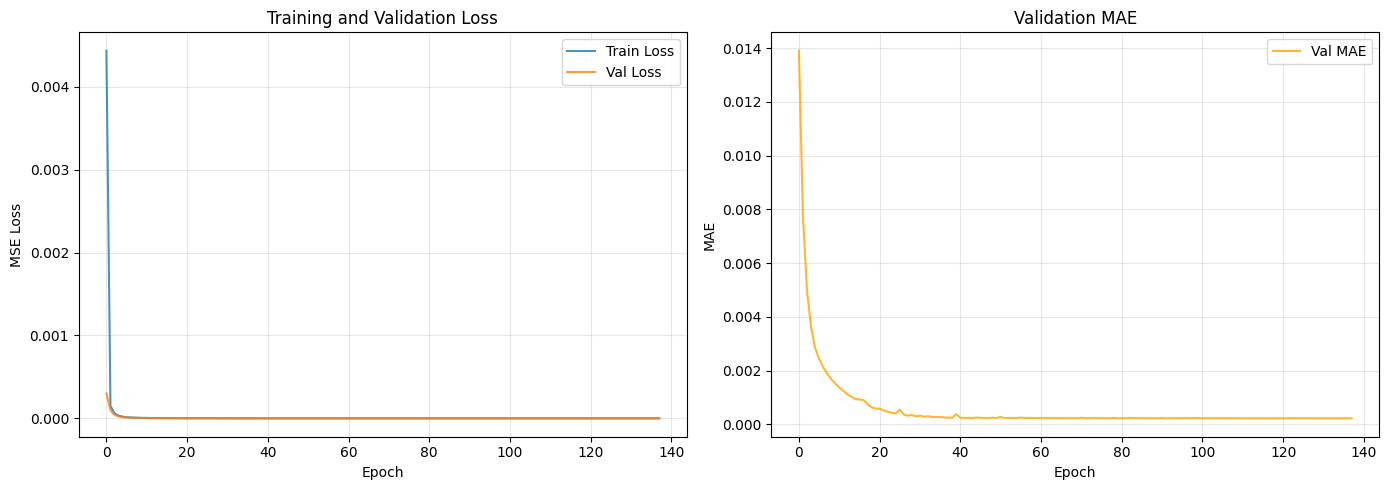

✓ Training completed in 138 epochs


In [57]:
import matplotlib.pyplot as plt

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(train_losses, label='Train Loss', alpha=0.8)
ax1.plot(val_losses, label='Val Loss', alpha=0.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# MAE curve
ax2.plot(val_maes, label='Val MAE', color='orange', alpha=0.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Validation MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Training completed in {len(train_losses)} epochs")

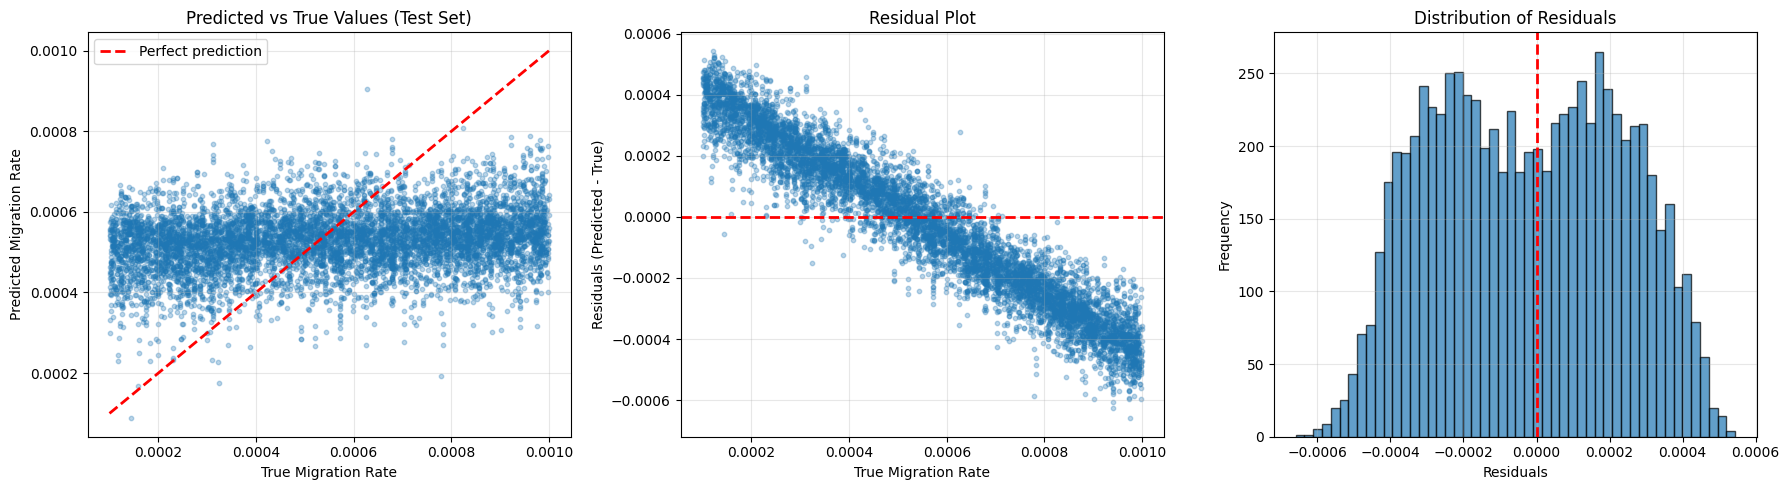

PREDICTION STATISTICS (Test Set)
Number of predictions: 7,740
Mean absolute error: 0.000221
Mean squared error: 0.000000
Residual mean: -0.000026
Residual std: 0.000255
Min residual: -0.000659
Max residual: 0.000544


In [58]:
import matplotlib.pyplot as plt

# Get predictions on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for graph in test_graphs:
        src_f, dst_f, labels = prepare_graph_data(graph)
        if len(labels) == 0:
            continue
        predictions = model(src_f, dst_f)
        all_preds.append(predictions)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter plot: Predicted vs True
ax1 = axes[0]
ax1.scatter(all_labels, all_preds, alpha=0.3, s=10)
ax1.plot([all_labels.min(), all_labels.max()], 
         [all_labels.min(), all_labels.max()], 
         'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('True Migration Rate')
ax1.set_ylabel('Predicted Migration Rate')
ax1.set_title('Predicted vs True Values (Test Set)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Residual plot
ax2 = axes[1]
residuals = all_preds - all_labels
ax2.scatter(all_labels, residuals, alpha=0.3, s=10)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('True Migration Rate')
ax2.set_ylabel('Residuals (Predicted - True)')
ax2.set_title('Residual Plot')
ax2.grid(True, alpha=0.3)

# 3. Histogram of residuals
ax3 = axes[2]
ax3.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Residuals')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Residuals')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("="*80)
print("PREDICTION STATISTICS (Test Set)")
print("="*80)
print(f"Number of predictions: {len(all_preds):,}")
print(f"Mean absolute error: {np.abs(residuals).mean():.6f}")
print(f"Mean squared error: {(residuals**2).mean():.6f}")
print(f"Residual mean: {residuals.mean():.6f}")
print(f"Residual std: {residuals.std():.6f}")
print(f"Min residual: {residuals.min():.6f}")
print(f"Max residual: {residuals.max():.6f}")
print("="*80)